In [ ]:
pip install -U datasets fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 20.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.5.1
    Uninstalling fsspec-2025.5.1:
      Successfully uninstalled fsspec-2025.5.1
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [ ]:
!pip install git+https://github.com/feralvam/easse.git



  Cloning https://github.com/feralvam/easse.git to /tmp/pip-req-build-xdi_57h3
  Running command git clone --filter=blob:none --quiet https://github.com/feralvam/easse.git /tmp/pip-req-build-xdi_57h3
  Resolved https://github.com/feralvam/easse.git to commit 6a4352ec299ed03fda8ee45445ca43d9c7673e89
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/facebookresearch/text-simplification-evaluation.git (to revision main) to /tmp/pip-install-btef2876/tseval_ea2f8673693f4e69bf218fc85953d716
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/text-simplification-evaluation.git /tmp/pip-install-btef2876/tseval_ea2f8673693f4e69bf218fc85953d716
  Resolved https://github.com/facebookresearch/text-simplification-evaluation.git to commit dea8863683ea5946fd50184883c9be7a7339e821
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   

In [ ]:
from datasets import load_dataset
import pandas as pd
from itertools import chain

# Load ASSET validation split
dataset = load_dataset("asset", split="validation")
df = dataset.to_pandas()

# Expand complex-simple pairs
def expand_data(df):
    return pd.DataFrame(list(chain.from_iterable([
        [{"original": src, "simplification": ref} for ref in refs]
        for src, refs in zip(df["original"], df["simplifications"])
    ])))

df_train = expand_data(df[:800])
df_test = df[800:].reset_index(drop=True)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


validation-00000-of-00001.parquet:   0%|          | 0.00/885k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


test-00000-of-00001.parquet:   0%|          | 0.00/170k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/359 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd

def expand_data(df):
    new_rows = []
    df = df.rename(columns={'simplifications': 'simplification'})
    for index, row in df.iterrows():
        for b_item in row['simplification']:
            new_rows.append({'original': row['original'], 'simplification': b_item})

    # Create a new DataFrame from the expanded data
    new_df = pd.DataFrame(new_rows)
    return new_df

In [ ]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

# Load model and tokenizer
model = T5ForConditionalGeneration.from_pretrained("t5-small")
tokenizer = T5Tokenizer.from_pretrained("t5-small")


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Modelo y tokenizer cargados correctamente ✅


In [ ]:
def simplify_text_t5(text, max_length=64):
    input_text = "simplify: " + text
    inputs = tokenizer(input_text, return_tensors="pt", truncation=True)

    output_ids = model.generate(
        inputs.input_ids,
        max_length=max_length,
        num_beams=4,
        early_stopping=True
    )

    simplified_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return simplified_text


In [ ]:
original_example = df_test.iloc[0]["original"]
simplified_example = simplify_text_t5(original_example)

print("Original:", original_example)
print("Simplificado:", simplified_example)



Original: The Higgs boson is the only Standard Model particle that has not yet been observed.
Simplificado: Einfacher: Der Higgs boson ist die einzige Standard Model-Partikel, die noch nicht beobachtet wurde.


In [ ]:

from transformers import T5Tokenizer, T5ForConditionalGeneration, Seq2SeqTrainer, Seq2SeqTrainingArguments
from datasets import Dataset

# Load tokenizer and model
tokenizer = T5Tokenizer.from_pretrained("t5-small")
model = T5ForConditionalGeneration.from_pretrained("t5-small")


In [ ]:

# Tokenization function for T5
def preprocess_function(examples):
    inputs = ["simplify: " + ex for ex in examples["original"]]
    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding="max_length")

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(examples["simplification"], max_length=128, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


In [ ]:

# Convert df_train to Hugging Face Dataset and tokenize
train_dataset = Dataset.from_pandas(df_train)
tokenized_train = train_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["original", "simplification"]
)


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3959: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [ ]:
# Training arguments
training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    num_train_epochs=3, # times the model goes through the dataset
    per_device_train_batch_size=8, # number of training examples processes
                                    # together in 1 step per device (GPU or CPU)
    save_total_limit=1, # limits the number of saved model versions to 1
                        # (helps save disk space)
    logging_dir="./logs",
    save_steps=500, # model saves progress every 500 step
    report_to="none"
)
# Trainer
trainer = Seq2SeqTrainer(
    model=model, # training model (t5-small)
    args=training_args,
    train_dataset=tokenized_train, # preprocessed training data
    tokenizer=tokenizer
)
# Train the model
trainer.train()


<ipython-input-9-e6412ea800fb>:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Step,Training Loss
500,0.755900
1000,0.207100
1500,0.195000
2000,0.192000
2500,0.187300
3000,0.186600


TrainOutput(global_step=3000, training_loss=0.28728362019856774, metrics={'train_runtime': 509.4962, 'train_samples_per_second': 47.105, 'train_steps_per_second': 5.888, 'total_flos': 812050808832000.0, 'train_loss': 0.28728362019856774, 'epoch': 3.0})

In [ ]:

# Redefine simplify_text to use the fine-tuned model
def simplify_text_t5(text, max_length=64):
    device = model.device 
    input_ids = tokenizer("simplify: " + text, return_tensors="pt", truncation=True).input_ids.to(device)
    output_ids = model.generate(input_ids, max_length=max_length, num_beams=4, early_stopping=True)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)



In [ ]:
from tqdm.auto import tqdm

tqdm.pandas()
df_test["generated"] = df_test["original"].progress_apply(simplify_text_t5)

  0%|          | 0/1200 [00:00<?, ?it/s]

In [ ]:
!git clone https://github.com/feralvam/easse.git
%cd easse
!pip install -e .

Cloning into 'easse'...
remote: Enumerating objects: 1964, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 1964 (delta 118), reused 104 (delta 104), pack-reused 1819 (from 1)
Receiving objects: 100% (1964/1964), 33.15 MiB | 29.09 MiB/s, done.
Resolving deltas: 100% (1231/1231), done.
/content/easse
Obtaining file:///content/easse
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/facebookresearch/text-simplification-evaluation.git (to revision main) to /tmp/pip-install-czs84sma/tseval_d29c4606d84149a6bd1cd40363183d9c
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/text-simplification-evaluation.git /tmp/pip-install-czs84sma/tseval_d29c4606d84149a6bd1cd40363183d9c
  Resolved https://github.com/facebookresearch/text-simplification-evaluation.git to commit dea8863683ea5946fd50184883c9be7a7339e821
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━

In [ ]:
from easse.sari import corpus_sari
from easse.bleu import sentence_bleu
from easse.fkgl import corpus_fkgl
import numpy as np
from tqdm.auto import tqdm
import nltk
nltk.download('punkt_tab')

# filter rows with no generated simplification
df_eval = df_test.dropna(subset=["generated"]).reset_index(drop=True)

saris = []
bleus = []

for i in tqdm(range(len(df_eval))):
    sari_score = corpus_sari(
        orig_sents=[df_eval.loc[i, "original"]],
        sys_sents=[df_eval.loc[i, "generated"]],
        # reference outputs
        refs_sents=[[ref] for ref in df_eval.loc[i, "simplifications"]],
        use_paper_version=True 
    )
    saris.append(sari_score)

    bleu_score = sentence_bleu(
        sys_sent=df_eval.loc[i, "generated"],
        ref_sents=df_eval.loc[i, "simplifications"]
    )
    bleus.append(bleu_score)

fkgl_score = corpus_fkgl(df_eval["generated"].tolist())


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


  0%|          | 0/1200 [00:00<?, ?it/s]

In [ ]:
print(f"SARI (↑): {np.mean(saris):.3f}")
print(f"BLEU (↑): {np.mean(bleus):.3f}")
print(f"FKGL (↓): {fkgl_score:.3f}")


SARI (↑): 34.030
BLEU (↑): 89.992
FKGL (↓): 7.850


In [ ]:
import pandas as pd
import os

results_file = "/mnt/data/T5-small_asset_results.csv"

def save_model_result(model_name, sari, bleu, fkgl):
    if os.path.exists(results_file):
        df = pd.read_csv(results_file)
    else:
        df = pd.DataFrame(columns=["Model", "SARI", "BLEU", "FKGL"])

    df = df[df["Model"] != model_name]

    df.loc[len(df)] = [model_name, sari, bleu, fkgl]
    df.to_csv(results_file, index=False)
    return df


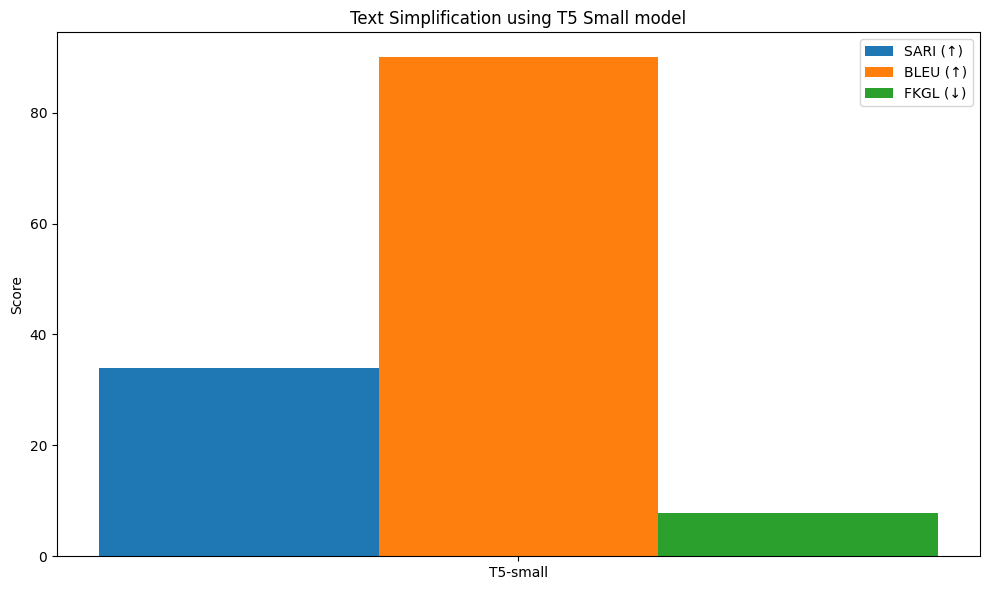

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("/mnt/data", exist_ok=True) 

df_updated = save_model_result(
    "T5-small",
    np.mean(saris),
    np.mean(bleus),
    fkgl_score
)

labels = df_updated['Model']                  
sari = df_updated['SARI']                      
bleu = df_updated['BLEU']                      
fkgl = df_updated['FKGL']                     

x = np.arange(len(labels))                    
width = 0.25                                 

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, sari, width, label='SARI (↑)')
bars2 = ax.bar(x, bleu, width, label='BLEU (↑)')
bars3 = ax.bar(x + width, fkgl, width, label='FKGL (↓)')

ax.set_ylabel('Score')
ax.set_title('Text Simplification using T5 Small model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')